In [34]:
import pylbsr.notebooks
import pylbsr.misc

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from dotmap import DotMap
from tqdm import tqdm

from scipy.stats import pearsonr

import parnet
from parnet_additional_utils import GzListDataset, ParnetModelName, load_parnet_model
from parnet.layers import LinearProjectionHead

⏱ 0.00 s (00:00:00)


In [2]:
_notebook_name = "03_integrated_gradients.ipynb"
_notebook_path = f"notebooks/globalclip-head/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[08:14:21] INFO - Project directory: /mnt/storage1/workspace/lhofer/parnet--globalclip-head


In [3]:
# ── GPU setup ──────────────────────────────────────────────────────────────────
pylbsr.misc.set_seed(42)

params_gpu_index = 0
device = torch.device(f"cuda:{params_gpu_index}")
torch.cuda.set_device(params_gpu_index)

if torch.cuda.is_available():
    logger.info(f"Using GPU: {torch.cuda.get_device_name(device)}")
else:
    logger.warning("No GPU available, using CPU instead.")

[08:14:25] INFO - Using GPU: NVIDIA RTX A4000


Seed set to 42
⏱ 0.10 s (00:00:00)


In [7]:
# ── Parameters ─────────────────────────────────────────────────────────────────
# Run to load the model from
EVAL_RUN = "parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50"

# Pretrained backbone this run was fine-tuned from
# or PARNET_21M_0_0 / PARNET_21M_NONE
PRETRAINED_MODEL = ParnetModelName.PARNET_7M_0_0

# Data used for this run (filtered or raw)
USE_FILTERED_DATA = True

# Integrated Gradients settings
params_n_steps: int = 50
params_n_sequences: int = None

# Data
params_seq_length: int = 600
params_num_tasks: int = 1

# ── Metamotif parameters ───────────────────────────────────────────────────────
params_sig_p = 0.05        # search significance threshold (was 0.01) — more sensitive
params_seed_size = 3       # search seed size
params_max_size = 20       # search max subsequence size
params_min_support = 20    # alignment: min k-mers to retain a motif (was 100)
params_max_motifs = 15     # alignment: max motifs to extract (was 5)

⏱ 0.00 s (00:00:00)


In [8]:
# ── Filepaths ──────────────────────────────────────────────────────────────────
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())

_data_key = "data_lysate_noNHS_filtered" if USE_FILTERED_DATA else "data_lysate_noNHS"

FILEPATHS = DotMap()
FILEPATHS["data"] = Path(_fp_cfg["global_clip"][_data_key])
FILEPATHS["pretrained_model"] = Path(_fp_cfg["models"][PRETRAINED_MODEL.value])
FILEPATHS["run_dir"] = PROJECT_DIR / "results" / "globalclip-head" / "training" / EVAL_RUN
FILEPATHS["output_dir"] = FILEPATHS["run_dir"] / "integrated_gradients"
FILEPATHS["figures_dir"] = PROJECT_DIR / "results" / "globalclip-head" / "figures"

FILEPATHS["output_dir"].mkdir(parents=True, exist_ok=True)
FILEPATHS["figures_dir"].mkdir(parents=True, exist_ok=True)

logger.info(f"Run dir:    {FILEPATHS.run_dir}")
logger.info(f"Output dir: {FILEPATHS.output_dir}")

[09:45:38] INFO - Run dir:    /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50
[09:45:38] INFO - Output dir: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients


⏱ 0.01 s (00:00:00)


In [9]:
# ── Load test dataset ──────────────────────────────────────────────────────────
test_ds = GzListDataset(
    FILEPATHS.data, split="test",
    length=params_seq_length, total_key="globalCLIP", control_key="control",
    shuffle=False, mmap=True,
)

n_sequences = len(test_ds) if params_n_sequences is None else params_n_sequences
logger.info(f"Test size: {len(test_ds)} — computing IG on {n_sequences} sequences")

Loading (mmap) globalclip_lysate_noNHS.minreads3.maxsignal1000.pt split='test'... 

[09:45:51] INFO - Test size: 4896 — computing IG on 4896 sequences


loaded 4896 samples.
⏱ 9.94 s (00:00:09)


In [11]:
# ── Load model ─────────────────────────────────────────────────────────────────
class GlobalCLIPHead(torch.nn.Module):
    def __init__(self, num_tasks=1):
        super().__init__()
        self.projection = LinearProjectionHead(num_tasks)

    def forward(self, inputs, **kwargs):
        logit = self.projection(inputs)
        logprob = logit - torch.logsumexp(logit, dim=-1, keepdim=True)
        return {
            'total': logprob,
            'mix_coeff': torch.ones(inputs.shape[0], 1, device=inputs.device),
        }

model = load_parnet_model(
    PRETRAINED_MODEL,
    FILEPATHS["pretrained_model"],
    dtype=torch.float32,
    device=device,
)

model.head = GlobalCLIPHead(num_tasks=params_num_tasks).to(device)

# initialize lazy parameters — derive hidden dim from the backbone (512 for 7M, 768 for 21M)
with torch.no_grad():
    _probe_seq = test_ds[0]["inputs"]["sequence"].unsqueeze(0).to(device)
    _backbone_out = model.body(model.stem(_probe_seq))
    _hidden_dim = _backbone_out.shape[1]
    model.head(_backbone_out)
logger.info(f"Backbone hidden dim: {_hidden_dim}")

# load fine-tuned weights
_checkpoint = torch.load(FILEPATHS["run_dir"] / "model.statedict.pt", map_location=device)
model.load_state_dict(_checkpoint["state_dict"])
model.eval()
logger.info(f"Model loaded from: {FILEPATHS.run_dir / 'model.statedict.pt'}")

[09:45:57] INFO - Backbone hidden dim: 512
[09:45:58] INFO - Model loaded from: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/model.statedict.pt


⏱ 0.41 s (00:00:00)


In [12]:
# ── Integrated Gradients implementation ────────────────────────────────────────
def integrated_gradients(model, sequence, n_steps=50):
    """
    Compute Integrated Gradients for a single sequence.
    
    Args:
        model: fine-tuned GlobalCLIP model
        sequence: (1, 4, 600) one-hot encoded sequence tensor
        n_steps: number of interpolation steps between baseline and input
    
    Returns:
        attributions: (4, 600) attribution scores
    """
    baseline = torch.zeros_like(sequence)  # all-zeros baseline (no information)
    
    # interpolate between baseline and input: (n_steps, 1, 4, 600)
    alphas = torch.linspace(0, 1, n_steps, device=sequence.device)
    interpolated = torch.stack([
        baseline + alpha * (sequence - baseline)
        for alpha in alphas
    ])  # (n_steps, 1, 4, 600)
    interpolated = interpolated.squeeze(1)  # (n_steps, 4, 600)
    interpolated.requires_grad_(True)
    
    # forward pass on all interpolated sequences at once
    output = model(sequence=interpolated)
    target = output['total'].sum()  # scalar
    
    # compute gradients
    target.backward()
    grads = interpolated.grad  # (n_steps, 4, 600)
    
    # average gradients and scale by (input - baseline)
    avg_grads = grads.mean(0)  # (4, 600)
    attributions = avg_grads * (sequence.squeeze(0) - baseline.squeeze(0))
    
    return attributions.detach().cpu()

⏱ 0.00 s (00:00:00)


In [13]:
# ── Compute IG for all test sequences ──────────────────────────────────────────
all_attributions = []
all_sequences = []

model.eval()
for i in tqdm(range(n_sequences)):
    sample = test_ds[i]
    
    # get one-hot encoded sequence (4, 600)
    sequence = sample["inputs"]["sequence"].unsqueeze(0).to(device)  # (1, 4, 600)
    
    # compute IG
    attrs = integrated_gradients(model, sequence, n_steps=params_n_steps)  # (4, 600)
    
    all_attributions.append(attrs.numpy())
    all_sequences.append(sample["inputs"]["sequence"].numpy())

all_attributions = np.stack(all_attributions)  # (n_sequences, 4, 600)
all_sequences = np.stack(all_sequences)         # (n_sequences, 4, 600)

logger.info(f"Computed IG for {n_sequences} sequences")
logger.info(f"Attribution maps shape: {all_attributions.shape}")

100%|██████████| 4896/4896 [08:10<00:00,  9.97it/s]
[09:54:15] INFO - Computed IG for 4896 sequences
[09:54:15] INFO - Attribution maps shape: (4896, 4, 600)


⏱ 490.95 s (00:08:10)


In [14]:
# ── Save attribution maps ──────────────────────────────────────────────────────
np.save(FILEPATHS["output_dir"] / "attributions.npy", all_attributions)
np.save(FILEPATHS["output_dir"] / "sequences.npy", all_sequences)
logger.info(f"Saved attribution maps → {FILEPATHS.output_dir}")

[09:55:51] INFO - Saved attribution maps → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients


⏱ 0.73 s (00:00:00)


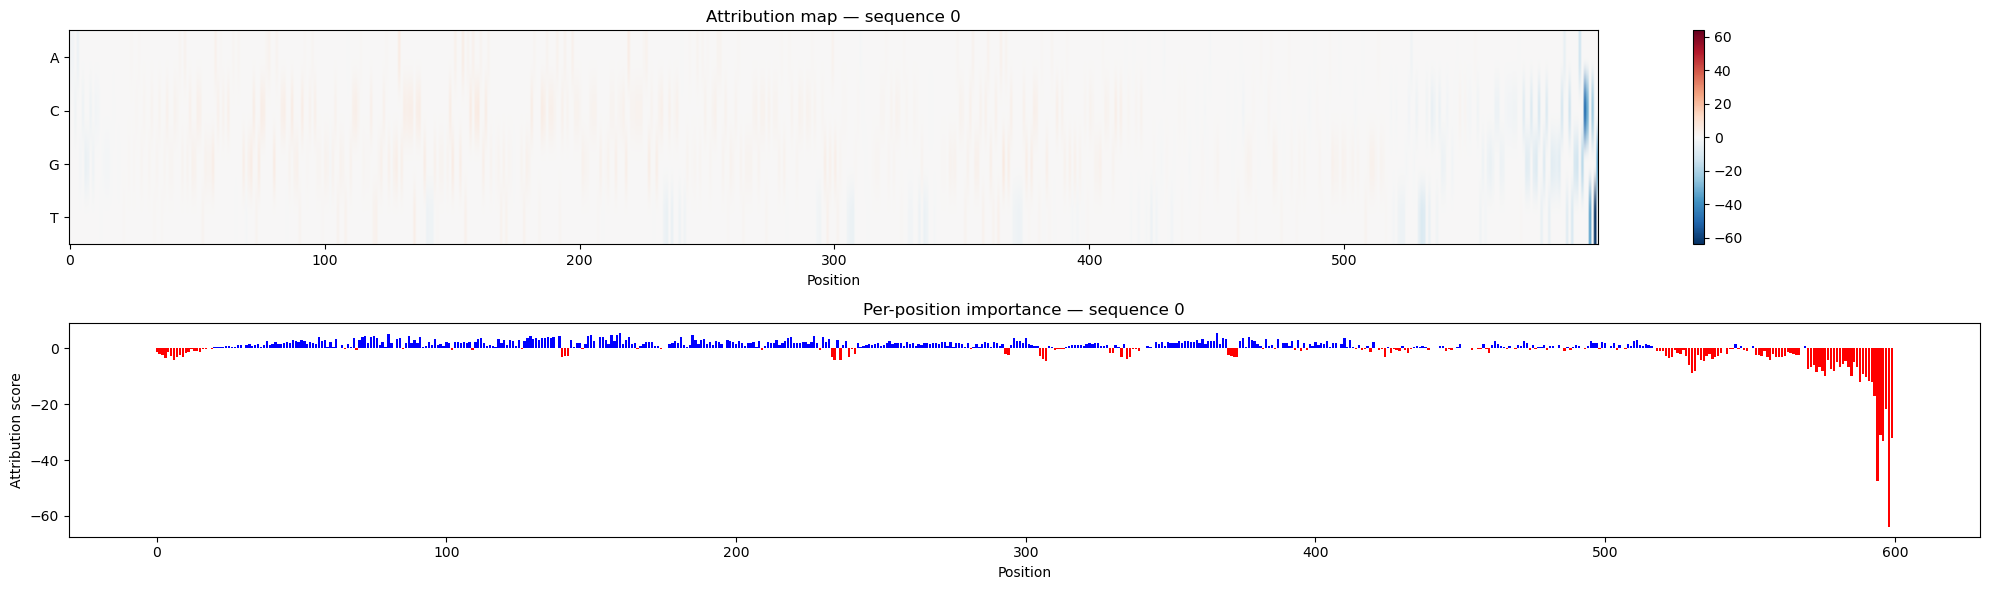

⏱ 1.19 s (00:00:01)


In [16]:
# ── Visualize single attribution map ───────────────────────────────────────────
NUCLEOTIDES = ["A", "C", "G", "T"]
SEQ_IDX = 0  # which sequence to visualize

fig, axes = plt.subplots(2, 1, figsize=(20, 6))

# ── Attribution map (4 nucleotides x 600 positions) ───────────────────────────
im = axes[0].imshow(
    all_attributions[SEQ_IDX],
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.abs(all_attributions[SEQ_IDX]).max(),
    vmax=np.abs(all_attributions[SEQ_IDX]).max(),
)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(NUCLEOTIDES)
axes[0].set_xlabel("Position")
axes[0].set_title(f"Attribution map — sequence {SEQ_IDX}")
plt.colorbar(im, ax=axes[0])

# ── Per-position importance (sum over nucleotides) ─────────────────────────────
importance = all_attributions[SEQ_IDX].sum(axis=0)  # (600,)
axes[1].bar(range(600), importance, color=["red" if v < 0 else "blue" for v in importance])
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Attribution score")
axes[1].set_title(f"Per-position importance — sequence {SEQ_IDX}")

plt.tight_layout()
plt.savefig(FILEPATHS["figures_dir"] / f"attribution_map_seq{SEQ_IDX}.png", dpi=150, bbox_inches="tight")
plt.show()

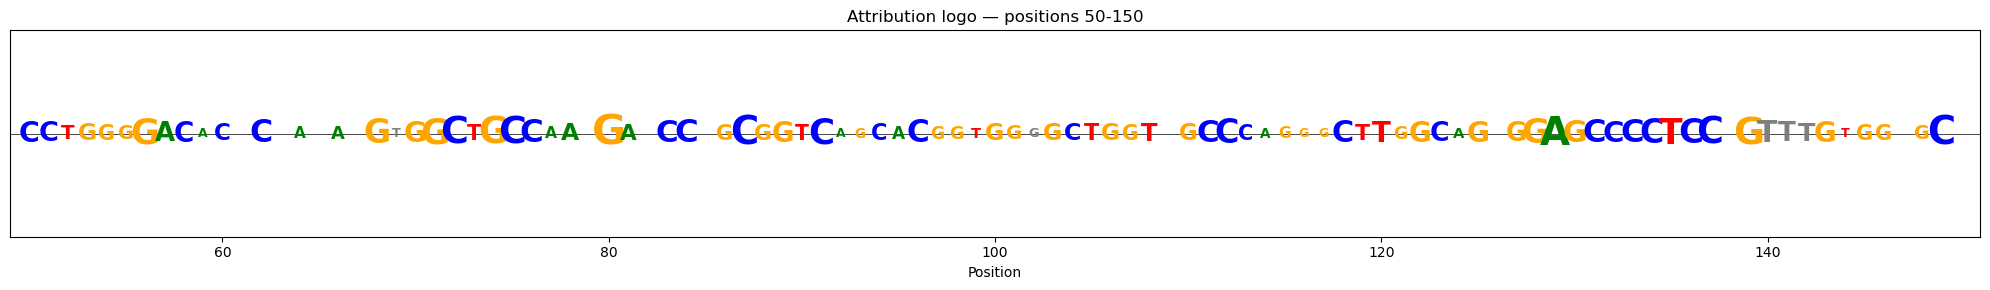

<Figure size 640x480 with 0 Axes>

⏱ 0.16 s (00:00:00)


In [18]:
def plot_attribution_logo(attributions, sequence, start=0, end=100, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 3))
    
    NUCLEOTIDES = ["A", "C", "G", "T"]
    COLORS = {"A": "green", "C": "blue", "G": "orange", "T": "red"}
    
    # normalize scores to make font sizes more visible
    max_score = np.abs(attributions[:, start:end]).max()
    
    for pos in range(start, end):
        for nuc_idx, nuc in enumerate(NUCLEOTIDES):
            if sequence[nuc_idx, pos] == 0:
                continue
            score = attributions[nuc_idx, pos]
            if abs(score) < 0.1 * max_score:  # skip bottom 10%
                continue
            fontsize = 6 + (abs(score) / max_score) * 24  # scale 6-30
            color = COLORS[nuc] if score > 0 else "gray"
            ax.text(
                pos, 0, nuc,
                fontsize=fontsize,
                color=color,
                ha="center", va="center",
                fontweight="bold",
            )
    
    ax.set_xlim(start - 1, end + 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("Position")
    ax.set_title(f"Attribution logo — positions {start}-{end}")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_yticks([])
    return ax

fig, ax = plt.subplots(figsize=(20, 3))
plot_attribution_logo(all_attributions[SEQ_IDX], all_sequences[SEQ_IDX], start=50, end=150, ax=ax)
plt.tight_layout()
plt.show()
plt.savefig(FILEPATHS["figures_dir"] / f"attribution_logo_seq{SEQ_IDX}.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# ── Load RBP motifs ────────────────────────────────────────────────────────────
import pylbsr.bio.motifs as motifs_lib
from pylbsr.bio.motifs.motif import convert_matrix_type

MOTIFS_DIR = Path("/mnt/storage1/ml4rg26-shared/rbp_binding_motifs")
DATABASES = ["mCrossBase", "ATtRACT", "RBPmap_1.2", "oRNAment", "RBPDB"]

def load_motif_ppm(f):
    """Load a .transfac motif and convert to PPM for scoring."""
    with open(f) as fh:
        ms = motifs_lib.read_motifs_transfac(fh)
    if not ms:
        return None
    m = ms[0]
    
    # get matrix type from filename (e.g. K562.PCM.000.transfac)
    mt = f.stem.split(".")[1].upper()  # PCM, PPM, PWM
    m.matrix_type = mt
    
    try:
        if mt in ("PCM", "PPM"):
            m = convert_matrix_type(m, "PPM")
        else:
            return None  # skip PWM
    except Exception:
        return None
    return m

# load all motifs
all_motifs = {}  # {rbp_name: [ppm_array, ...]}
for db in DATABASES:
    preproc = MOTIFS_DIR / db / "preprocessed"
    if not preproc.exists():
        continue
    for rbp_dir in preproc.iterdir():
        if not rbp_dir.is_dir():
            continue
        rbp = rbp_dir.name
        for f in rbp_dir.glob("*.transfac"):
            m = load_motif_ppm(f)
            if m is None:
                continue
            if rbp not in all_motifs:
                all_motifs[rbp] = []
            all_motifs[rbp].append(m.matrix.to_numpy(dtype=float))

logger.info(f"Loaded motifs for {len(all_motifs)} RBPs")

[09:57:38] INFO - Loaded motifs for 430 RBPs


⏱ 48.71 s (00:00:48)


In [21]:
# ── Convert attributions to importance scores + reconstruct sequences ──────────
NUCLEOTIDE_ARR = np.array(["A", "C", "G", "T"])

# per-position importance = sum of attribution over the 4 nucleotides → (n_seq, 600)
importance_scores = all_attributions.sum(axis=1)

# reconstruct sequence strings from one-hot encoding
def onehot_to_string(onehot):
    """(4, 600) one-hot → 'ACGT...' string via argmax over the nucleotide axis."""
    idx = onehot.argmax(axis=0)  # (600,)
    return "".join(NUCLEOTIDE_ARR[idx])

sequence_strings = [onehot_to_string(seq) for seq in all_sequences]

logger.info(f"Importance scores shape: {importance_scores.shape}")
logger.info(f"Reconstructed {len(sequence_strings)} sequence strings")
logger.info(f"Example seq:  {sequence_strings[0][:60]}...")
logger.info(f"Example imp:  {importance_scores[0][:6]}")

[09:57:50] INFO - Importance scores shape: (4896, 600)
[09:57:50] INFO - Reconstructed 4896 sequence strings
[09:57:50] INFO - Example seq:  AACAGCGGCGCCTGGGGCAGCTCGAGCAGCTGCTGCTGCGGCCAGAGCGGCCTGGGGACA...
[09:57:50] INFO - Example imp:  [-1.2938534 -1.9826607 -2.2576544 -3.2777553 -1.2468046 -2.8088305]


⏱ 0.37 s (00:00:00)


In [23]:
# ── Write FASTA + scores.npy for metamotif ─────────────────────────────────────
METAMOTIF_DIR = FILEPATHS["output_dir"] / "metamotif"
METAMOTIF_DIR.mkdir(parents=True, exist_ok=True)

_fasta_path  = METAMOTIF_DIR / "sequences.fasta"
_scores_path = METAMOTIF_DIR / "scores.npy"

# write FASTA — one record per sequence, header is the test-set index
with open(_fasta_path, "w") as fh:
    for i, seq in enumerate(sequence_strings):
        fh.write(f">seq_{i}\n{seq}\n")

# write importance scores as (n_seq, 600) numpy array
np.save(_scores_path, importance_scores)

logger.info(f"Wrote {len(sequence_strings)} sequences → {_fasta_path}")
logger.info(f"Wrote scores {importance_scores.shape} → {_scores_path}")

[09:57:55] INFO - Wrote 4896 sequences → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/sequences.fasta
[09:57:55] INFO - Wrote scores (4896, 600) → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/scores.npy


⏱ 0.11 s (00:00:00)


In [24]:
# ── Write metamotif search config (higher sensitivity) ─────────────────────────
_search_config = METAMOTIF_DIR / "search.config.gin"
_search_config.write_text(
    f"search.seed_size = {params_seed_size}\n"
    f"search.max_size = {params_max_size}\n"
    f"search.sig_p = {params_sig_p}\n"
)
logger.info(f"Wrote search config → {_search_config}")

[09:57:58] INFO - Wrote search config → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/search.config.gin


⏱ 0.03 s (00:00:00)


In [25]:
# ── Run metamotif search ───────────────────────────────────────────────────────
import subprocess

_kmers_path = METAMOTIF_DIR / "motifs.kmers.tsv"

# metamotif search {fasta} {scores.npy} --config {config} -o {output.tsv}
_cmd = [
    "metamotif", "search",
    str(_fasta_path),
    str(_scores_path),
    "--config", str(_search_config),
    "-o", str(_kmers_path),
]

logger.info(f"Running: {' '.join(_cmd)}")
_result = subprocess.run(_cmd, capture_output=True, text=True)

if _result.returncode != 0:
    logger.error(f"metamotif failed:\n{_result.stderr}")
else:
    logger.info(f"metamotif search complete → {_kmers_path}")
    print(_result.stdout[-500:] if _result.stdout else "(no stdout)")

[09:58:04] INFO - Running: metamotif search /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/sequences.fasta /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/scores.npy --config /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/search.config.gin -o /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/motifs.kmers.tsv
[10:00:19] INFO - metamotif search complete → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.he

(no stdout)
⏱ 135.05 s (00:02:15)


In [27]:
# ── Inspect metamotif output ───────────────────────────────────────────────────
import pandas as pd

kmers_df = pd.read_csv(
    _kmers_path, sep="\t", header=None,
    names=["seq_id", "subsequence", "importance", "start", "end", "length"],
)
logger.info(f"metamotif extracted {len(kmers_df)} subsequences")
print(kmers_df.head(10))
print(f"\nLength distribution:\n{kmers_df['length'].value_counts().sort_index()}")

[10:00:30] INFO - metamotif extracted 57015 subsequences


  seq_id subsequence  importance  start  end  length
0  seq_0       CTCCT     15.6864    134  139       5
1  seq_0       CCACC     15.9196    185  190       5
2  seq_0       GACCC     13.6648    218  223       5
3  seq_0       AGCCC     18.0667    129  134       5
4  seq_0       CCAAT     11.8326     75   80       5
5  seq_0       GATAC     17.4184    153  158       5
6  seq_0       AGAGC     16.6869    365  370       5
7  seq_0       GCTGC     19.0397     71   76       5
8  seq_0       CGAGG     16.1189    149  154       5
9  seq_0       CCAGC     18.9123    159  164       5

Length distribution:
length
5     56548
7       253
9        58
11       29
13       14
15        9
17        2
19        3
21       99
Name: count, dtype: int64
⏱ 0.06 s (00:00:00)


In [28]:
# ── Align k-mers into consensus motifs ─────────────────────────────────────────
_align_script = PROJECT_DIR / "externals" / "metamotif" / "scripts" / "variable-length-seed-motif-alignment.py"
_motifs_out_dir = METAMOTIF_DIR / "aligned_motifs"
_motifs_out_dir.mkdir(parents=True, exist_ok=True)

_cmd = [
    "python", str(_align_script),
    str(_kmers_path),
    "--min-support", str(params_min_support),
    "--max-motifs", str(params_max_motifs),
    "-o", str(_motifs_out_dir),
]

logger.info(f"Running: {' '.join(_cmd)}")
_result = subprocess.run(_cmd, capture_output=True, text=True)

if _result.returncode != 0:
    logger.error(f"Alignment failed:\n{_result.stderr}")
else:
    logger.info(f"Alignment complete → {_motifs_out_dir}")
    print(_result.stdout[-1000:] if _result.stdout else "(no stdout)")

[10:00:46] INFO - Running: python /mnt/storage1/workspace/lhofer/parnet--globalclip-head/externals/metamotif/scripts/variable-length-seed-motif-alignment.py /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/motifs.kmers.tsv --min-support 20 --max-motifs 15 -o /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/aligned_motifs


[10:01:39] INFO - Alignment complete → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/aligned_motifs


(no stdout)
⏱ 53.12 s (00:00:53)


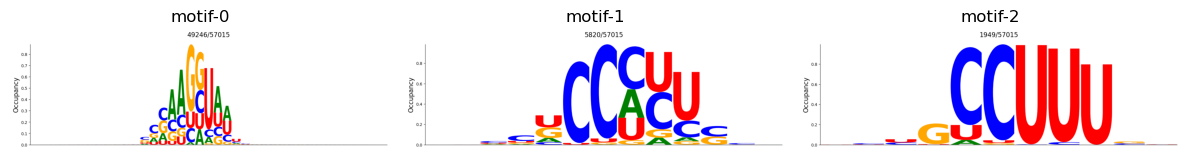

⏱ 0.42 s (00:00:00)


In [29]:
# ── Display consensus motif logos ──────────────────────────────────────────────
from PIL import Image

motif_pngs = sorted(_motifs_out_dir.glob("motif-*.png"))
fig, axes = plt.subplots(1, len(motif_pngs), figsize=(4 * len(motif_pngs), 3))
if len(motif_pngs) == 1:
    axes = [axes]
for ax, png in zip(axes, motif_pngs):
    ax.imshow(Image.open(png))
    ax.set_title(png.stem)
    ax.axis("off")
plt.tight_layout()
_run_label = EVAL_RUN.split(".globalclip")[0]  # e.g. "parnet.21m-0.0.unfreeze_last_2_layers"
plt.savefig(FILEPATHS["figures_dir"] / f"consensus_motifs.{_run_label}.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# ── Load consensus motif PPMs ──────────────────────────────────────────────────
def load_consensus_ppm(tsv_path):
    """Load a metamotif consensus motif TSV into a (L, 4) PPM array.
    Format: first line is '#support=N', then header 'A C G U', then rows.
    Columns are A, C, G, U (RNA) — we map U→T for matching against DNA PPMs.
    """
    df = pd.read_csv(tsv_path, sep="\t", comment="#")
    # columns are A, C, G, U → treat U as T
    mat = df[["A", "C", "G", "U"]].to_numpy(dtype=float)
    row_sums = mat.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return mat / row_sums

consensus_motifs = {}
for tsv in sorted(_motifs_out_dir.glob("motif-*.tsv")):
    consensus_motifs[tsv.stem] = load_consensus_ppm(tsv)
    logger.info(f"{tsv.stem}: PPM shape {consensus_motifs[tsv.stem].shape}")

[10:02:31] INFO - motif-0: PPM shape (39, 4)
[10:02:31] INFO - motif-1: PPM shape (13, 4)
[10:02:31] INFO - motif-2: PPM shape (11, 4)


⏱ 0.02 s (00:00:00)


In [35]:
# ── Match consensus motifs against RBP database ────────────────────────────────
def best_pcc(query_ppm, target_ppm, min_overlap_frac=0.8):
    """Best sliding-window PCC between two PPMs of shape (L, 4).
    Requires overlap to be at least min_overlap_frac of the shorter motif,
    so a tiny window of a long motif can't score a lucky perfect match.
    """
    L1, L2 = len(query_ppm), len(target_ppm)
    required_overlap = int(np.ceil(min_overlap_frac * min(L1, L2)))
    best = -np.inf
    for shift in range(-(L2 - required_overlap), L1 - required_overlap + 1):
        s1 = max(0, shift)
        e1 = min(L1, shift + L2)
        s2 = s1 - shift
        e2 = s2 + (e1 - s1)
        if e1 - s1 < required_overlap:
            continue
        a = query_ppm[s1:e1].flatten()
        b = target_ppm[s2:e2].flatten()
        if a.std() == 0 or b.std() == 0:
            continue
        r, _ = pearsonr(a, b)
        if np.isfinite(r):
            best = max(best, r)
    return best if best > -np.inf else np.nan

# match each consensus motif against all RBPs
match_results = {}
for motif_name, query_ppm in consensus_motifs.items():
    rbp_best = {}
    for rbp, motif_list in all_motifs.items():
        best = max((best_pcc(query_ppm, m) for m in motif_list), default=np.nan)
        if np.isfinite(best):
            rbp_best[rbp] = best
    top_rbps = sorted(rbp_best.items(), key=lambda x: x[1], reverse=True)[:10]
    match_results[motif_name] = top_rbps

# print results
for motif_name, top_rbps in match_results.items():
    print(f"\n{motif_name} → top matching RBPs:")
    for rbp, score in top_rbps:
        print(f"   {rbp:15s}  PCC={score:.3f}")


motif-0 → top matching RBPs:
   NFKB1            PCC=0.923
   SRP54            PCC=0.923
   ZRANB2           PCC=0.888
   F2               PCC=0.878
   RBM5             PCC=0.863
   TERT             PCC=0.855
   PPR10            PCC=0.805
   SF1              PCC=0.799
   RBM4             PCC=0.791
   DAZAP1           PCC=0.790

motif-1 → top matching RBPs:
   RPO21            PCC=0.864
   SRSF5            PCC=0.852
   RBM23            PCC=0.851
   PCBP2            PCC=0.847
   MSS116           PCC=0.840
   SRP19            PCC=0.826
   SRP68            PCC=0.826
   SRP54            PCC=0.826
   PCBP1            PCC=0.825
   SRSF2            PCC=0.818

motif-2 → top matching RBPs:
   TLR3             PCC=0.929
   ORB2             PCC=0.925
   TIAL1            PCC=0.894
   MSS116           PCC=0.872
   RC3H1            PCC=0.864
   TIA1             PCC=0.862
   RPO21            PCC=0.856
   PTBP1            PCC=0.853
   IFIH1            PCC=0.848
   NUDT21           PCC=0.842
⏱ 30.69 s 

In [38]:
# ── Inspect information content per motif ──────────────────────────────────────
def information_content(ppm):
    """Per-position information content (bits) of a (L, 4) PPM."""
    with np.errstate(divide="ignore", invalid="ignore"):
        entropy = -np.nansum(ppm * np.log2(ppm + 1e-10), axis=1)
    return 2.0 - entropy

for name, ppm in consensus_motifs.items():
    ic = information_content(ppm)
    print(f"\n{name} (len {len(ppm)}):")
    print(f"  IC per position: {np.round(ic, 2)}")
    print(f"  min={ic.min():.2f}, max={ic.max():.2f}, mean={ic.mean():.2f}")


motif-0 (len 39):
  IC per position: [1.   0.56 0.35 0.02 0.04 0.08 0.22 0.13 0.06 0.07 0.05 0.03 0.16 0.13
 0.13 0.35 0.41 0.66 0.11 1.01 0.16 0.21 0.2  0.27 0.01 0.04 0.06 0.03
 0.07 0.08 0.08 0.07 0.18 0.01 0.09 0.12 0.06 0.08 2.  ]
  min=0.01, max=2.00, mean=0.24

motif-1 (len 13):
  IC per position: [2.   0.42 0.22 0.46 0.24 1.86 1.6  0.27 0.35 0.69 0.98 1.47 1.  ]
  min=0.22, max=2.00, mean=0.89

motif-2 (len 11):
  IC per position: [2.   1.22 1.03 1.83 1.12 1.7  1.97 1.82 2.   1.04 0.44]
  min=0.44, max=2.00, mean=1.47
⏱ 0.00 s (00:00:00)


In [44]:
# ── Save motif → RBP matches ───────────────────────────────────────────────────
import json

match_out = {
    motif: [{"rbp": rbp, "pcc": round(float(score), 4)} for rbp, score in top_rbps]
    for motif, top_rbps in match_results.items()
}

_match_path = METAMOTIF_DIR / "rbp_matches.json"
_match_path.write_text(json.dumps(match_out, indent=2))
logger.info(f"Saved RBP matches → {_match_path}")

[10:06:21] INFO - Saved RBP matches → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/training/parnet.7m-0.0.head.globalclip-lysate-noNHS.filtered.noctrl.ep50/integrated_gradients/metamotif/rbp_matches.json


⏱ 0.01 s (00:00:00)
